# 02 · Text Models — DistilBERT vs TF-IDF vs Zero-shot
This notebook **displays** the results of the trained models (training is done by the scripts, so the notebook is deterministic and safe to re-run).

### How the models were trained (reference command)
```bash
python src/train_text_models.py --distilbert --epochs 12
```

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd, numpy as np
from src import config
from src.utils import load_json
tm=load_json(config.METRICS_DIR/'text_model_metrics.json')
rows=[{'model_target':k,'accuracy':m['accuracy'],'macro_f1':m['macro_f1'],'mean_conf':m.get('mean_confidence'),'epochs':m.get('epochs','-')} for k,m in tm['models'].items()]
pd.DataFrame(rows)

,model_target,accuracy,macro_f1,mean_conf,epochs
0,tfidf_issue,1.0000,1.0000,0.7602,-
1,tfidf_churn,1.0000,1.0000,0.8494,-
2,distilbert_issue,0.9841,0.9841,0.9127,12
3,distilbert_churn,1.0000,1.0000,0.9868,12


## Confusion matrices

tfidf_issue_confusion.png


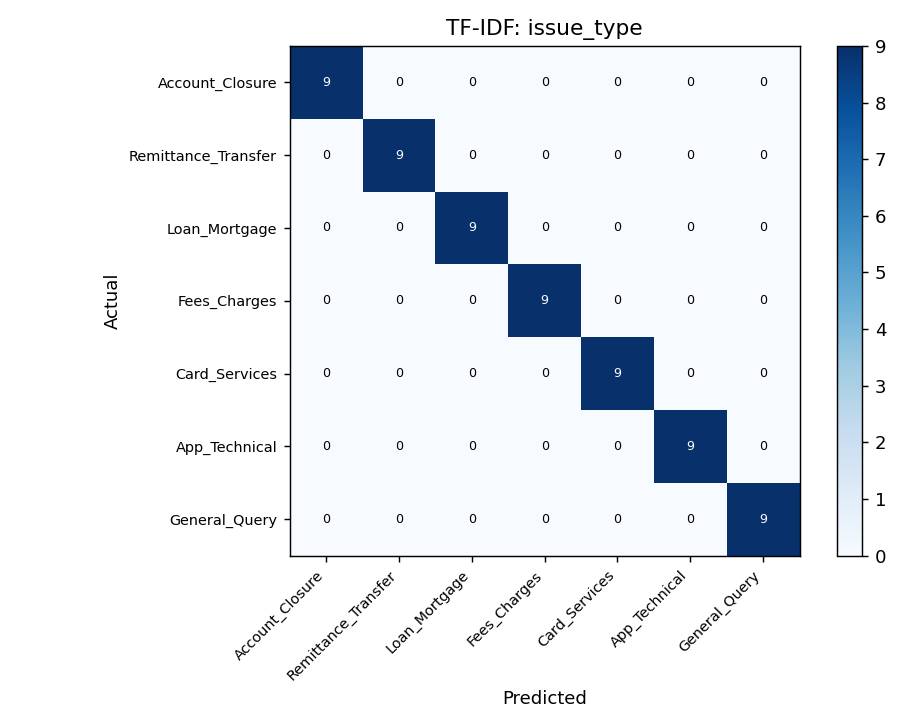

distilbert_issue_confusion.png


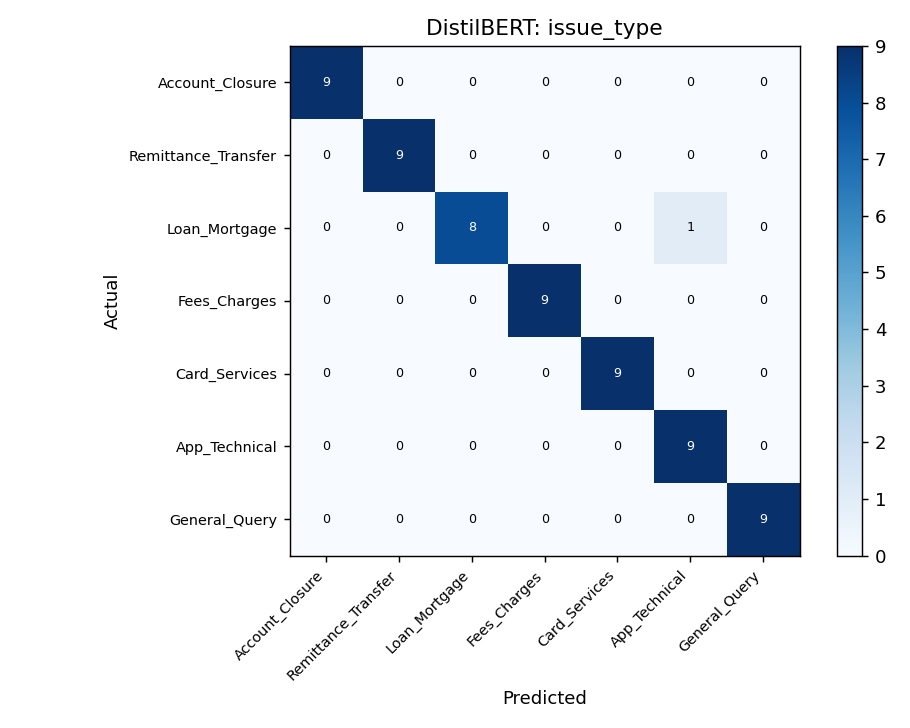

tfidf_churn_confusion.png


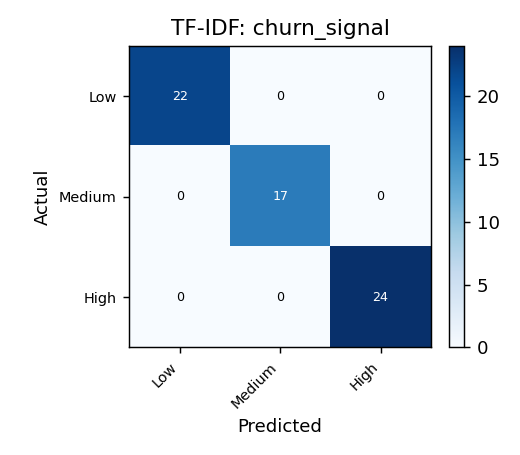

distilbert_churn_confusion.png


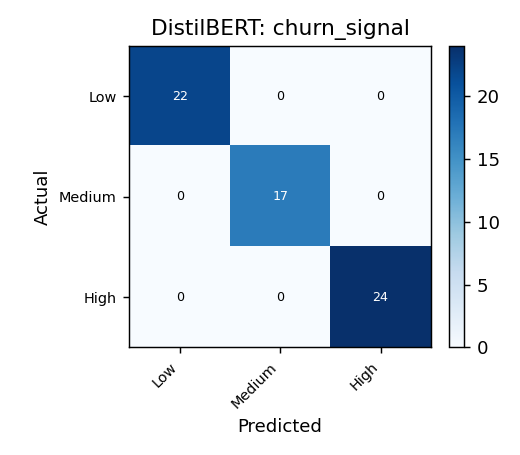

In [2]:
from IPython.display import Image, display
for f in ['tfidf_issue_confusion.png','distilbert_issue_confusion.png','tfidf_churn_confusion.png','distilbert_churn_confusion.png']:
    p=config.FIGURES_DIR/f
    if p.exists(): print(f); display(Image(str(p)))

## Per-language fairness (TF-IDF issue classifier)

In [3]:
pl=load_json(config.METRICS_DIR/'per_language_fairness.json')
pd.DataFrame(pl['per_language']).T

,language_name,n,accuracy,mean_confidence
ar,Arabic,12,1.0,0.7615
en,English,30,1.0,0.8239
hi,Hindi,6,1.0,0.7255
tl,Tagalog,15,1.0,0.6455


## Innovation: trained vs zero-shot LLM bake-off
Reference command: `python -m src.zero_shot_compare`

In [4]:
zs=load_json(config.METRICS_DIR/'zero_shot_comparison.json')
display(pd.DataFrame(zs['results']).T)
print('Winner:', zs['winner'])
print('Zero-shot accuracy by language:', zs['zero_shot_accuracy_by_language'])
print('\nFinding:', zs['finding'])
print('\nHonesty caveat:', zs['honesty_caveat'])

,accuracy,macro_f1,type
tfidf_logreg,1.0,1.0,trained (classical)
distilbert,1.0,1.0,trained (fine-tuned transformer)
zero_shot_qwen0.5b,0.5476,0.4986,"zero-shot (no training, prompt only)"


Winner: tfidf_logreg
Zero-shot accuracy by language: {'ar': 0.5556, 'en': 0.6364, 'hi': 0.0, 'tl': 0.5}

Finding: On 42 stratified messages, the trained models (tfidf_logreg, distilbert) far outperform the zero-shot Qwen-0.5B LLM (0.55 acc). At this data scale, a small OWNED model wins on accuracy, latency, cost and privacy — the zero-shot LLM struggles on short, templated, multilingual text with an English-first tokenizer. This is the expected and honest result the brief asks us to report.

Honesty caveat: The sample is drawn from the full dataset, so the trained models may have seen some of these rows during training — their 1.00 here partly reflects memorization. The FAIR reference is the held-out test split (TF-IDF issue 1.00, DistilBERT 0.984). The zero-shot model saw no training data, so its number is a clean generalization read. Even against the held-out trained numbers, zero-shot loses decisively.


### Honest finding
Trained models saturate this templated synthetic data (TF-IDF 1.00, DistilBERT issue 0.984 held-out). A zero-shot Qwen-0.5B loses decisively (~0.55) and is very uneven across languages — small OWNED models win on accuracy, latency, cost and privacy at this scale.